In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSV and filter to newest results only (2025-12-15)
df = pd.read_csv('graphtoken_results.csv', parse_dates=['timestamp'])
df = df[df['timestamp'].dt.date == pd.to_datetime('2025-11-30').date()].copy()
# keep only runs with more than 1 epoch as before
df_clean = df[df['epochs'] > 1].copy()
sns.set_theme(style="whitegrid")

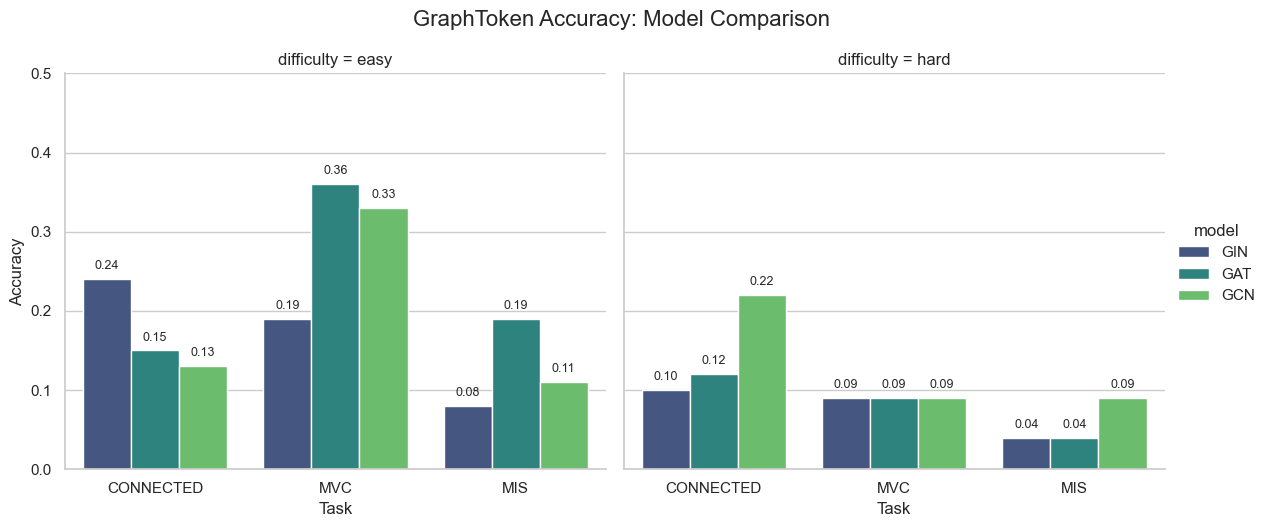

In [14]:
g = sns.catplot(
    data=df_clean,
    x="task",
    y="accuracy",
    hue="model",
    col="difficulty",
    kind="bar",
    palette="viridis",
    height=5,
    aspect=1.2,
    col_order=['easy', 'hard']
)
g.set(ylim=(0, 0.5))
g.fig.suptitle("GraphToken Accuracy: Model Comparison", y=1.05, fontsize=16)
g.set_axis_labels("Task", "Accuracy")
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')
plt.show()

In [15]:
# Inspect filtered dataframe
print("df_clean shape:", df_clean.shape)
print(df_clean.timestamp.min(), df_clean.timestamp.max())
print(df_clean.epochs.unique())

# Count rows per (task,difficulty,model)
print(df_clean.groupby(['task','difficulty','model']).size().sort_values(ascending=False))

# Show pivot and how many non-NaNs it has
heatmap_data = df_clean.pivot_table(index="task", columns=["difficulty","model"], values="accuracy")
print(heatmap_data)
print("non-NaN cells:", heatmap_data.notna().sum().sum())
print("NaNs per column:\n", heatmap_data.isna().sum())

df_clean shape: (18, 13)
2025-11-30 13:26:37.529032 2025-11-30 16:09:15.274456
[20]
task       difficulty  model
CONNECTED  easy        GAT      1
                       GCN      1
MVC        hard        GCN      1
                       GAT      1
           easy        GIN      1
                       GCN      1
                       GAT      1
MIS        hard        GIN      1
                       GCN      1
                       GAT      1
           easy        GIN      1
                       GCN      1
                       GAT      1
CONNECTED  hard        GIN      1
                       GCN      1
                       GAT      1
           easy        GIN      1
MVC        hard        GIN      1
dtype: int64
difficulty  easy              hard            
model        GAT   GCN   GIN   GAT   GCN   GIN
task                                          
CONNECTED   0.15  0.13  0.24  0.12  0.22  0.10
MIS         0.19  0.11  0.08  0.04  0.09  0.04
MVC         0.36  0.33  0.1

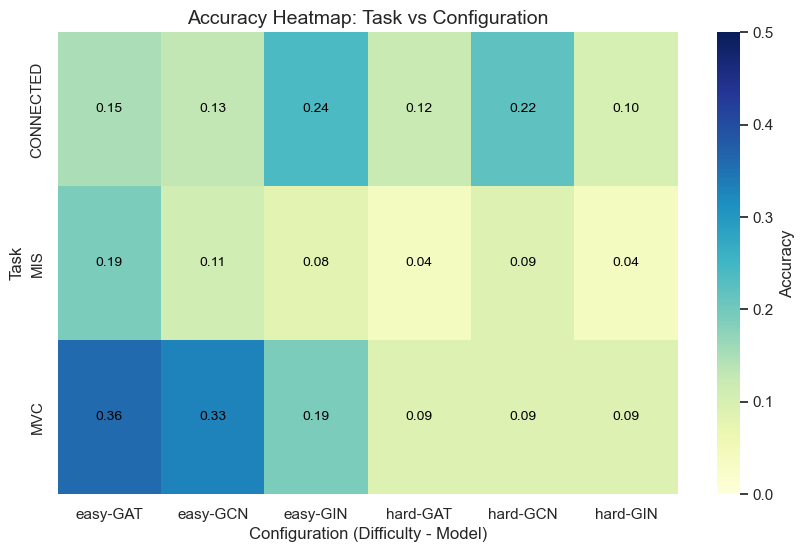

In [16]:
heatmap_data = df_clean.pivot_table(index="task", columns=["difficulty", "model"], values="accuracy")
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, annot=False, cmap="YlGnBu", vmin=0, vmax=0.5, cbar_kws={'label': 'Accuracy'})

# Manually annotate all cells
for i, row_label in enumerate(heatmap_data.index):
    for j, col_label in enumerate(heatmap_data.columns):
        value = heatmap_data.iloc[i, j]
        if not pd.isna(value):
            ax.text(j + 0.5, i + 0.5, f'{value:.2f}', 
                   ha='center', va='center', fontsize=10, color='black')

plt.title("Accuracy Heatmap: Task vs Configuration", fontsize=14)
plt.xlabel("Configuration (Difficulty - Model)")
plt.ylabel("Task")
plt.show()

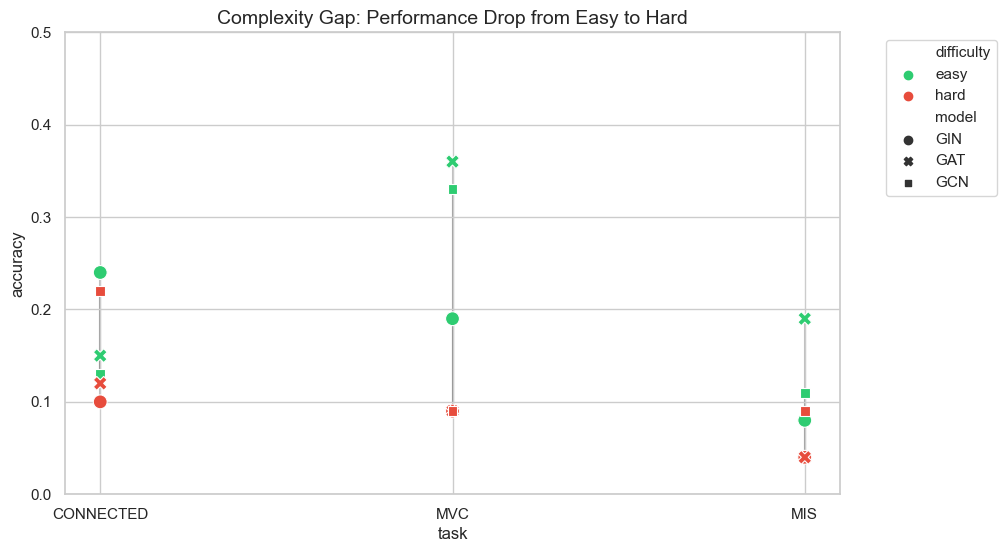

In [17]:
plt.figure(figsize=(10, 6))
# Plot easy/hard points
sns.scatterplot(data=df_clean, x='task', y='accuracy', hue='difficulty',
                style='model', s=100, palette=['#2ecc71', '#e74c3c'])

# Draw connecting lines
df_gap = df_clean.pivot_table(index=['task', 'model'], columns='difficulty', values='accuracy').reset_index()
for i in range(len(df_gap)):
    row = df_gap.iloc[i]
    plt.plot([row['task'], row['task']], [row['easy'], row['hard']], color='gray', alpha=0.5, zorder=0)

plt.ylim(0, 0.5)
plt.title("Complexity Gap: Performance Drop from Easy to Hard", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()